# Data Science Project 

## Research Question : - Does the adoption of electric cars reduce NOx emissions from road transport ? 

### By Alina Loacker, Amanda Loeb and Max Laurent

#### Under the supervision of Dr. Edoardo Chiarotti and Dr. Quentin Gallea

Midterm : Data Science & Causal Inference for Sustainability

## 1. Overview : 

This report studies whether the growing adoption of electric passenger cars is associated with lower nitrogen oxide emissions from road transport. 

The analysis combines Eurostat vehicle-stock data, EEA emissions inventories and also World Bank population data. 

The preliminary evidence shows two clear descriptive patterns:
- First of all, electric-vehicle adoption rises across European countries, meanwhile NOx emissions decline in the focus countries Norway and Sweden. These observed patterns motivate the research question, but they do not yet set a causal effect. Therefore, the final analysis requires a country and year model with fixed-effects along with explicit
robustness checks.

- The report follows the midterm requirements: it defines a causal research question, explains the data and transformations, show the sample and cleaning choices. It also depicts preliminary univariate and bivariate analysis and finally discusses the main threats to causal interpretation.

## 2. Why does it matter? 

Our research question is:      Does the adoption of electric cars reduce NOx emissions from road transport?

The question is causal because it asks whether a change in electric-car adoption causes a change in an environmental outcome. The outcome is NOx emissions measured in kilotonnes per country and year. 

The main explanatory variable would be the stock or share of electric passenger cars. 

Furthermore, population density or urbanisation are used to study if  the relationship differs across places. Moreover, NOx refers to nitrogen oxides : meaning mainly nitric oxide and nitrogen dioxide. In fact, these pollutants are produced during high-temperature combustion and can harm respiratory health. It contributes to ozone formation and damage ecosystems as a whole. Therefore, on the one hand, road transport is relevant because emissions happens close to people.  On the other hand, passenger cars are an important part of road traffic emissions.

Finally, electric-car policies are usually justified by their potential to reduce CO2 emissions. If electric cars also reduce local NOx emissions, they generate an additional air-quality, that we can call : co-benefit. This matters for policy because the social value of EV adoption would not only include climate benefits but also health benefits.

## 3. Literature review 

The literature generally suggests that electric vehicles can improve air quality, but the size of the effect depends on several factors such as : the setting but also the electricity mix and the research model.

- Ferrero et al. (2016) simulate emission scenarios near a highway in Milan. Replacing 50% of combustion vehicles with pure electric ones reduces NO2 by 5.5% and NO by 16%, but low replacement rates show little effect. Limitation: simulation, short period, very local area.

- Holland et al. (2016) study the USA and show that benefits depend strongly on local factors, mainly on how electricity is produced. Benefits are large in Los Angeles but negative in the Midwest. Limitation: data from 2010-2012 only.

- Choma et al. (2020) use an epidemiological model and find positive health benefits in every US metropolitan area, with larger estimates than Holland et al. Limitation: model-based, not an observational causal estimate.

- Andersson & Breuer (2021) use a panel of 290 Swedish municipalities (2010-2019) and OLS with municipality and year fixed effects. They find an elasticity of about -0.03 (significant at 1%). Limitations: NOx covers the whole transport sector, many omitted variables, missing values coded as 0, and fragile robustness.

Our project extends this literature in three ways : 

First, it uses a broader European country-year range. 

Second, it focuses on passenger-car NOx emissions rather than only total transport emissions. 

Third, it compares pooled patterns with within-country changes. Finally, it includes plans to study whether the relationship differs by population density.



## 4. Variables


| Variable | Role | Source and construction |
|---|---|---|
| Passenger-car NOx emissions | Outcome | EEA inventory. Keep NOx, “Road transport: Passenger cars”, unit kt/year. |
| Total NOx emissions | Context and denominator | EEA inventory. Keep “National total for the entire territory (based on fuel sold)”. |
| Pure electric-car stock | Main explanatory variable | Eurostat `road_eqs_carpda`. Keep `mot_nrg = ELC` and `leg_form = TOTAL`. |
| Total passenger-car stock | Denominator and control | Eurostat `road_eqs_carpda`. Keep `mot_nrg = TOTAL` and `leg_form = TOTAL`. |
| Population | Per-capita measure and control | World Bank population indicator, reshaped to country-year format. |
| Population density | Heterogeneity variable | To be added from Eurostat or the World Bank. |



# Transformations

The raw EV stock is strongly right-skewed and grows quickly over time. Therefore we constructed an EV share and considered logarithmic transformations. The EV share is then calculated as : electric passenger cars divided by total passenger cars, multiplied by 100. 

EVs per capita can also be used to reduce the influence of country size. Moreover, when both log(NOx) and log(EV stock) let the coefficient to be interpreted as an elasticity.Which is subject to handling zero values, carefully.

# Measurement limitations
- The EEA emissions data are inventory estimates based on fuel sold, not direct roadside measurements.
- The current EV measure counts pure electric cars only. However, Hybrids and plug-in hybrids are not included.
- Filtering leg_form to TOTAL is crucial to avoid counting the same cars across legal-form categories.
- Country-level data hide differences between urban and rural areas.

## Step 1: Sample

The working sample is an annual country-year panel created by merging the cleaned EV, NOx and population data by country and year. Additionnaly, the EV figures are between 2016–2024. The EEA emissions series begins earlier and is used for both context and trend comparisons.

| Step | Operation | Reason |
|---|---|---|
| 1 | Filter the EV file to ELC and TOTAL, keep `leg_form = TOTAL`, and remove missing EV or total-car values. | Creates a consistent EV share denominator. |
| 2 | Filter emissions to `pollutantName = NOx` and remove rows with missing values. | Keeps the outcome variable relevant to the research question. |
| 3 | Keep the EEA national-total and passenger-car road-transport sectors. | Makes total and passenger-car emissions comparable. |
| 4 | Drop EEA32 and EU27 aggregates and harmonise country names. | Prevents aggregates from being treated as countries and allows a valid merge. |
| 5 | Merge population and calculate per-capita measures. | Reduces the influence of country size. |


The EEA source has 4,511,772 rows and 10 columns before filtering. The population file contains 265 rows and 71 columns before it is reshaped. 

## Univariate analysis: Electric-vehicle adoption
The EV data show an increase in adoption between 2016 and 2024. Second, the distribution of the absolute EV stock rises over time. However, absolute counts are partly a measure of country size. The EV share is therefore more informative for comparing countries.

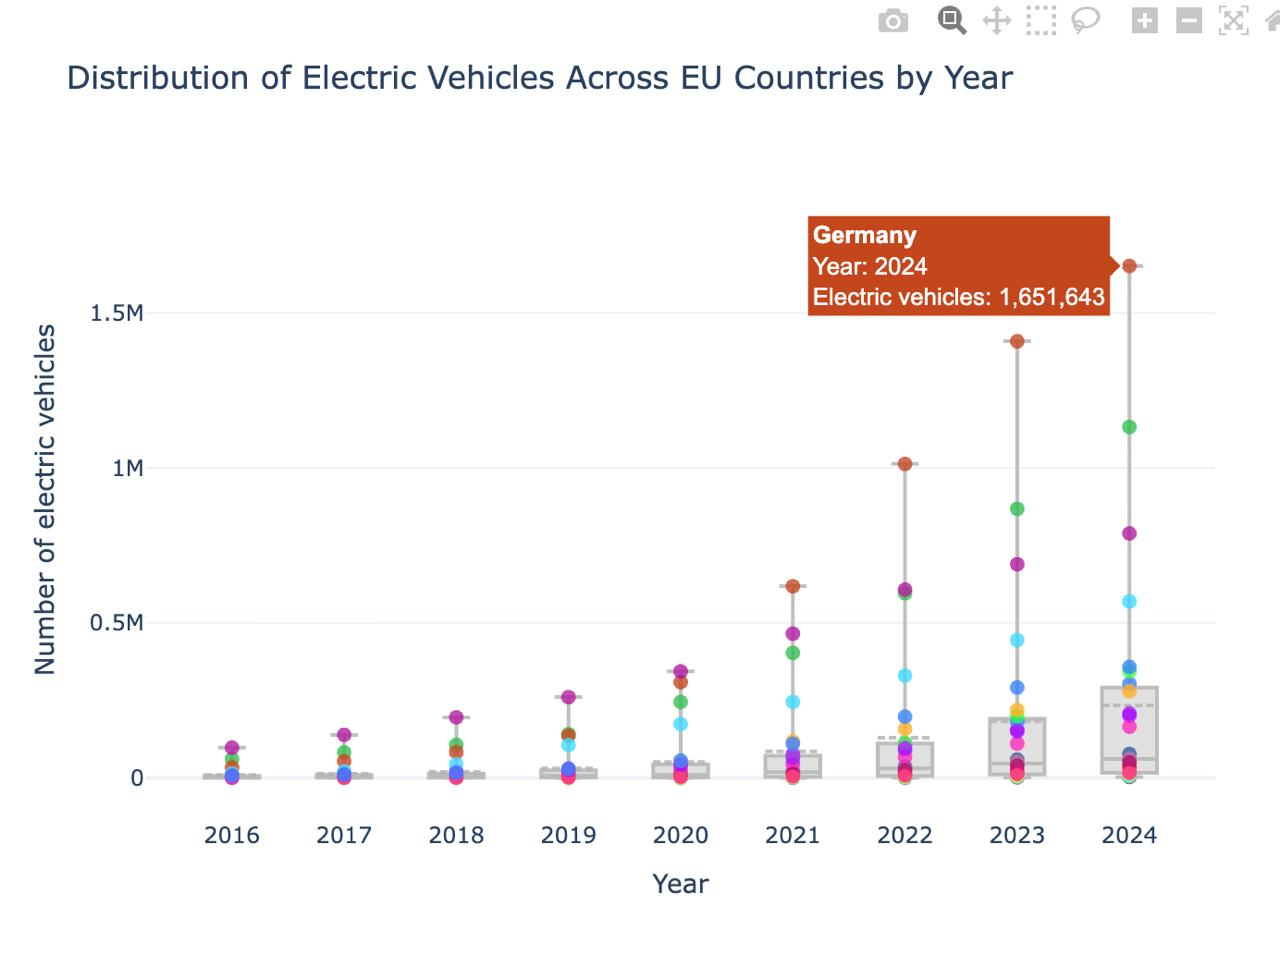

Figure 1. Distribution of the absolute electric-vehicle stock across European countries by year. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

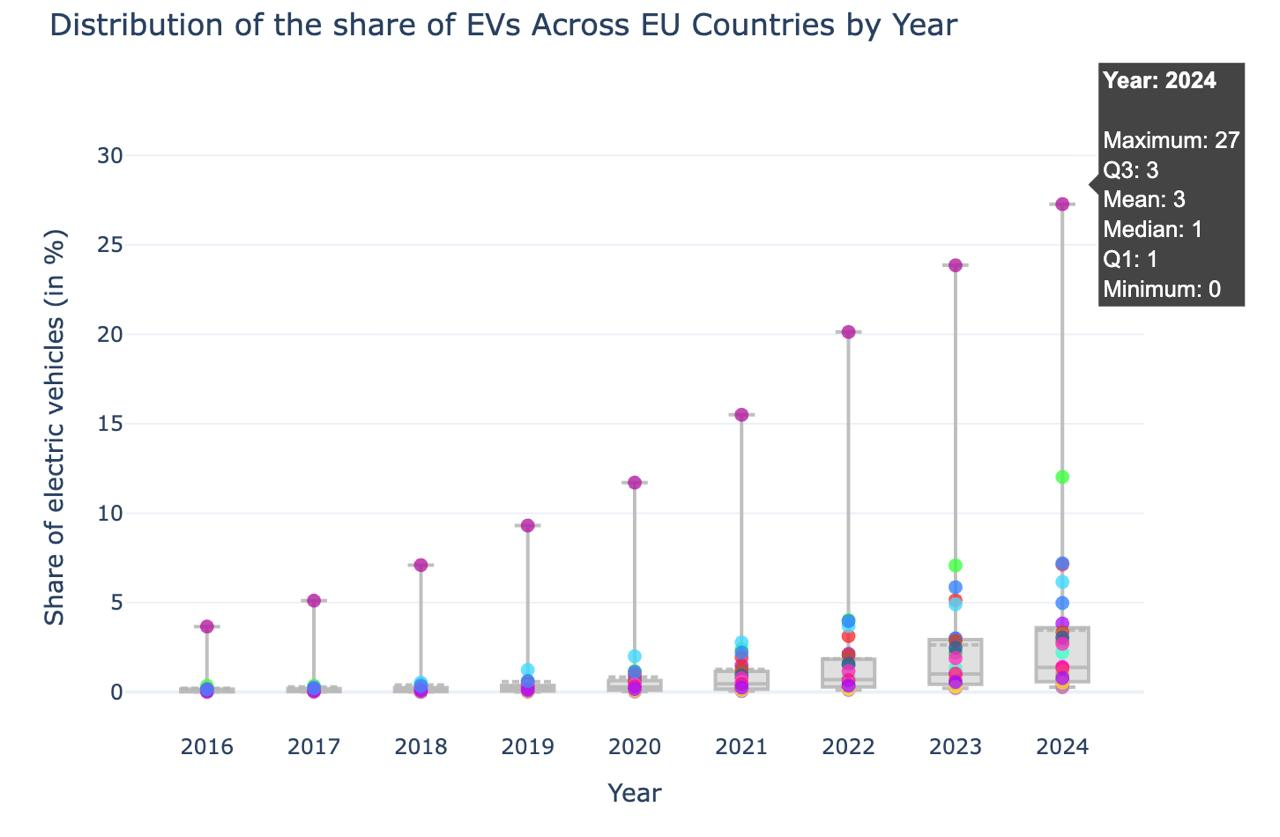
Figure 2. Distribution of the electric-vehicle share across European countries by year. Source: team data-cleaning notebooks using Eurostat, EEA and World Bank data.

The median EV share increases with time and the cross-country spread widens. Norway is then : a clear outlier with a much higher EV share than the rest of the sample. We can highlight that this outlier is very interesting because it provides a strong case for studying heterogeneity. Nevertheless, it also creates a risk that a pooled relationship is driven by one country. 

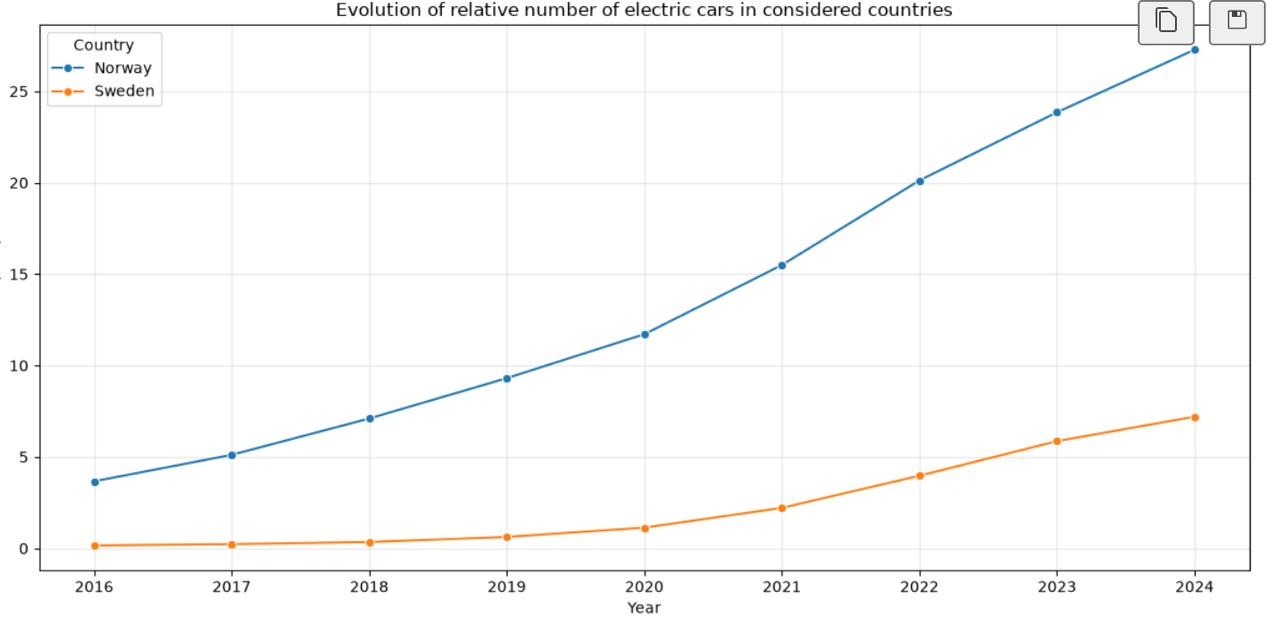

Figure 3. EV-share trends in Norway and Sweden. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

Norway depicts a much faster increase than Sweden. Both countries follow an upward trend but their levels differ a lot. This contrast encourages the robustness check that excludes Norway and the use of within-country comparisons.

NOx emissions and descriptive outcomes. The cleaned emissions data allow us to distinguish total NOx emissions from passenger-car road-transport NOx emissions. This distinction is important because the research question is about the channel most directly affected by EV adoption.

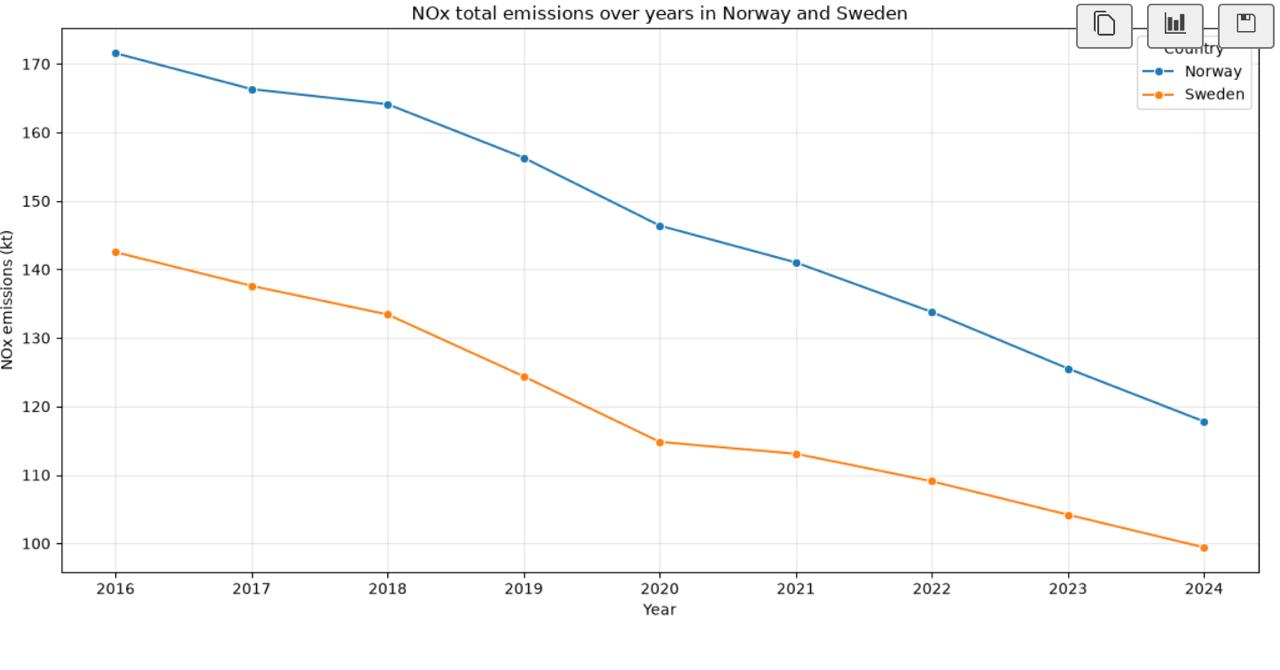
Figure 4. Total NOx emissions in Norway and Sweden, 2016–2024. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

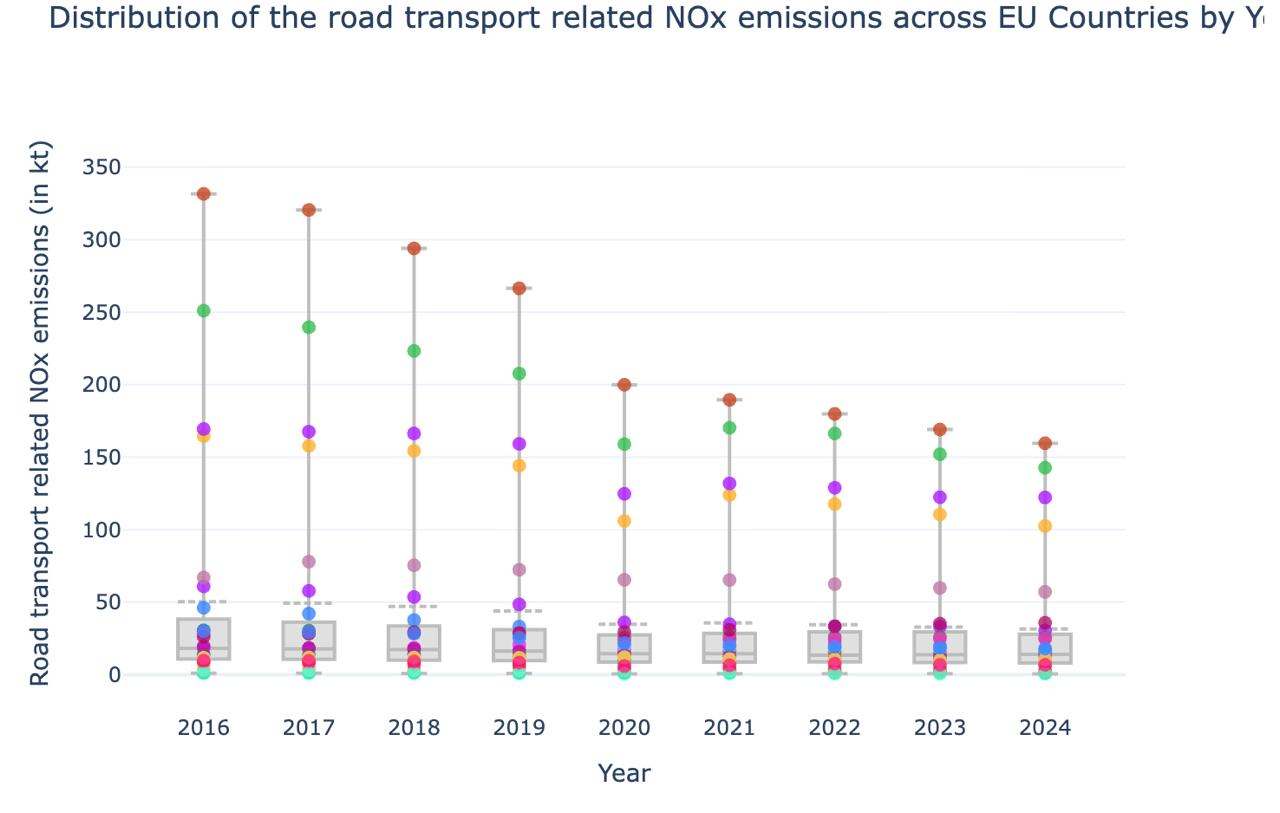
Figure 5. Distribution of passenger-car road-transport NOx emissions across European countries by year. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

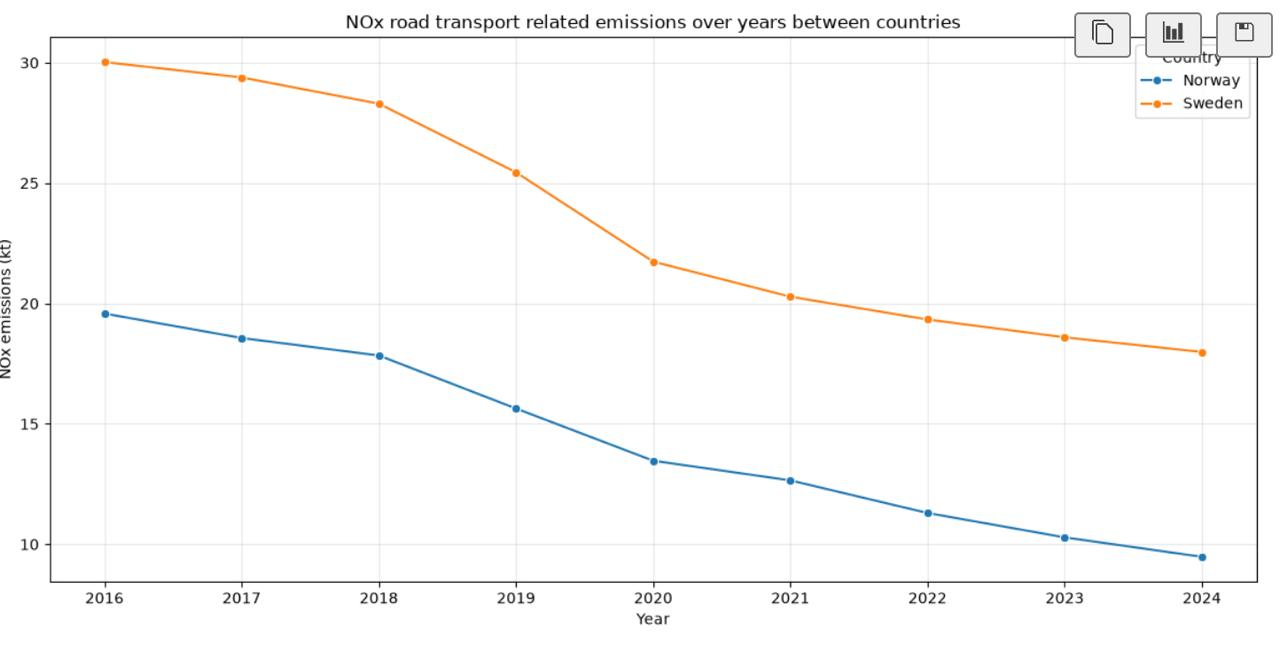
Figure 6. Passenger-car road-transport NOx emissions in Norway and Sweden, 2016–2024. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

We can clearly see that total NOx emissions decline in both countries. Passenger-car road-transport NOx also declines with a fall over the period. The cross-country distribution remains wide. This phenomenon reinforces the importance of doing it for country size and controlling it for country-specific aspects.

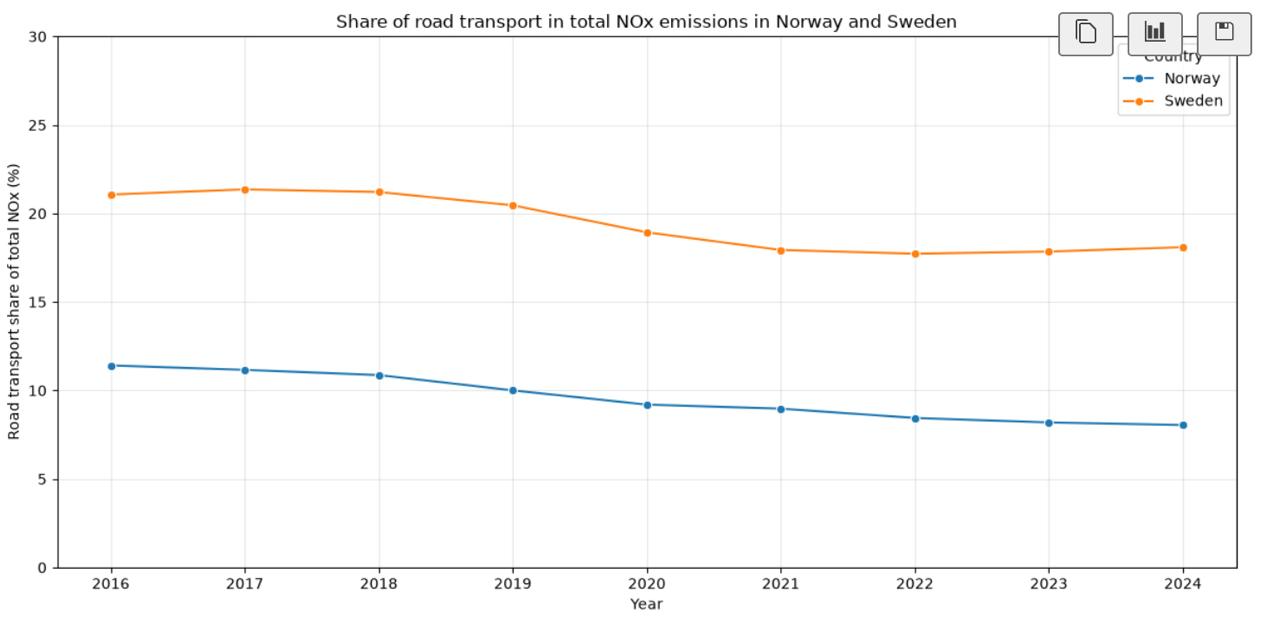
Figure 7. Passenger-car road-transport NOx as a share of total NOx in Norway and Sweden. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

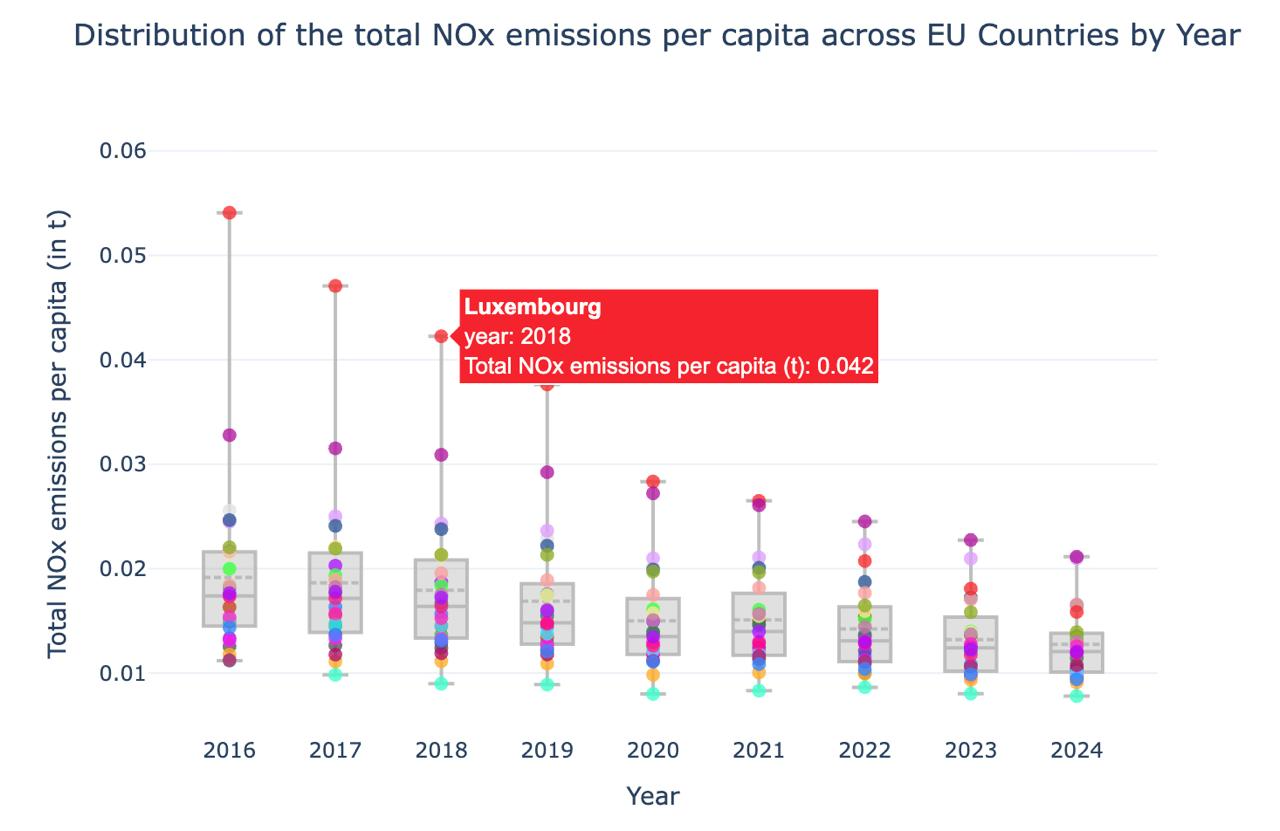
Figure 8. Distribution of total NOx emissions per capita across European countries by year. Source: data-cleaning notebooks using Eurostat, EEA and World Bank data.

Furthermore, in the countries analysed, the road-transport share of total NOx decreases over time. In fact, the per-capita aspect shows why population should be included. Indeed, raw totals can make large countries appear more polluted even when their
emissions per person are relatively low. Per-capita normalisation improves the comparable aspect but it does not remove confounding or reverse causality.

## Bivariate EDA and within-country comparison

The univariate figures suggest a negative descriptive relationship: EV adoption rises while NOx emissions fall, particularly in Norway and Sweden. However, this comparison is not yet a bivariate causal result. Both variables change over time, and country size, income, regulation and fleet composition differ across countries.

Planned bivariate analysis
- Plot pooled log(NOx) against log(EV stock) to show the raw cross-country relationship.
- Remove country means and repeat the scatter plot to focus on within-country changes.
- Report correlations between log(NOx), EV share, total cars and population or density.
- Estimate the fixed-effects model only after checking the common support, outliers and missingness.

The pooled relationship may be misleading because large countries have both more vehicles and more emissions. The within-country relationship is more informative for the causal question, but it still requires year effects and additional controls. The current data-cleaning notebooks do not yet report a pooled coefficient, a within-country coefficient or a correlation table, so no numerical causal conclusion should be drawn at this stage.

## Causality issues : Main threats to causal interpretation

| Question | Risk in this project |
|---|---|
| Is there something else? | Income, education, environmental preferences, fleet renewal, diesel share, weather, and emission standards may affect both EV adoption and NOx. |
| Is it the reverse? | Places with worse air quality may adopt EVs more quickly. Subsidies, charging infrastructure, and low-emission zones may drive both variables. |
| Can we extrapolate? | Norway is an outlier, and electricity mix, urban form, income, and policy differ across countries. |
| How is the outcome measured? | EEA NOx is modelled inventory data based on fuel sold. It is not a direct measure of street-level exposure. |





## Next Steps : Baseline model

log(NOx_it) = α_i + λ_t + β log(EV_it) + γ′X_it + ε_it

The controls should include total passenger-car stock, population density, income and, if available, the diesel share of the fleet. 

Standard errors should be clustered by country. The main robustness checks should exclude
2020–2021 because the COVID-19 period changed mobility also emissions and exclude Norway because it is an extreme EV-adoption outlier. 

A policy-based difference or a type of instrumental variable design can be considered later on but only if the policy timing are defensible.

Finally, the current evidence supports a clear and testable hypothesis, not a final causal claim and conclusion. The next analysis should therefore complete the merged-sample summary table. But also produce the pooled and within-country bivariate figures. Thus, through estimating the model with fixed-effects and report how sensitive the estimate is, in order to checks of the robustness we would propose.



## References and data sources : 

- Andersson, S. and Breuer, A. (2021). Are There Co-benefits on Air Quality from Adopting Electric Cars?
An empirical study of the effect electric cars have on air pollution in Sweden. Bachelor thesis, Department
of Economics, Uppsala University.
- Choma, E. F., Evans, J. S., Hammitt, J. K., Gómez-Ibáñez, J. A. and Spengler, J. D. (2020). Assessing the
health impacts of electric vehicles through air pollution in the United States. Environment International,
144, 106015.
- Ferrero, E., Alessandrini, S. and Balanzino, A. (2016). Impact of the electric vehicles on the air pollution
from a highway. Applied Energy, 169, 450–459.
- Holland, S. P., Mansur, E. T., Muller, N. Z. and Yates, A. J. (2016). Are There Environmental Benefits
from Driving Electric Vehicles? The Importance of Local Factors. American Economic Review, 106(12),
3700–3729.
- European Environment Agency. Air pollutant emissions data, including NOx by sector and country.
- Eurostat. Passenger cars by type of motor energy, dataset road_eqs_carpda.
- World Bank. Population, total, indicator SP.POP.TOTL.







